<a href="https://colab.research.google.com/github/bhanuprakash227/DataScience_ExcelR_Assignments/blob/main/13_XGBM%26LGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**LGBM & XGBM**

##**Objective:**
The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the diabetes dataset.


**Data Preprocessing**

In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

df = pd.read_csv("diabetes (2).csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nSummary Statistics:")
print(df.describe())

Dataset Shape: (768, 9)

First 5 Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64

**Exploratory Data Analysis**

In [13]:

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nTarget Distribution:")
print(df["Outcome"].value_counts())

print("\nTarget Percentage:")
print(df["Outcome"].value_counts(normalize=True) * 100)

print("\nUnique Values:")
print(df.nunique())

print("\nPotential Zero Values:")
print((df == 0).sum())

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate Rows: 0

Target Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Target Percentage:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Unique Values:
Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

Potential Zero Values:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI             

**Data Visualization**

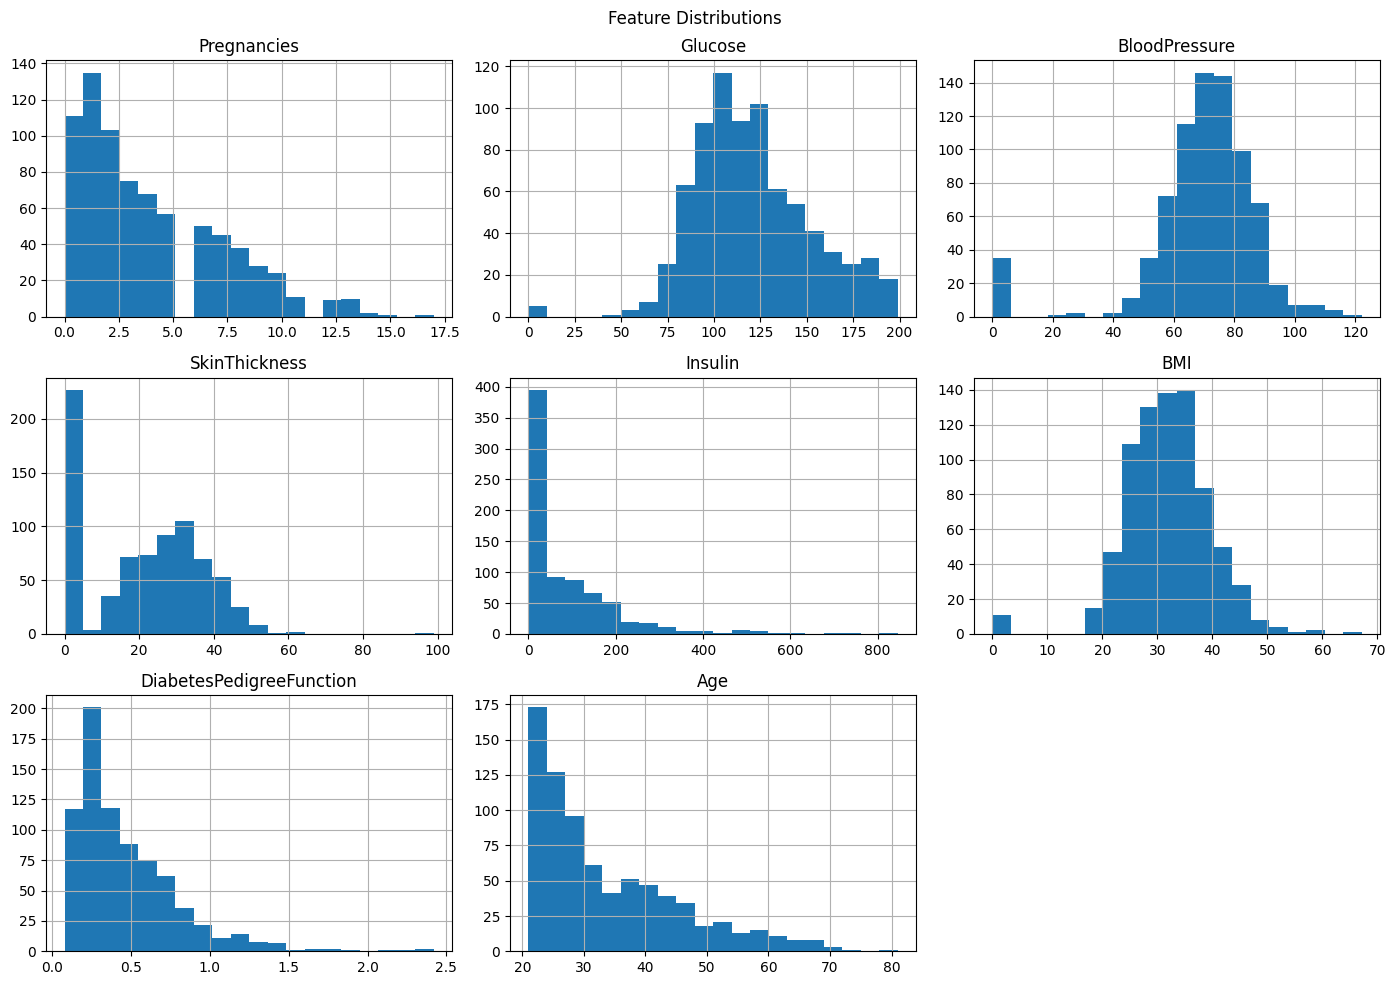

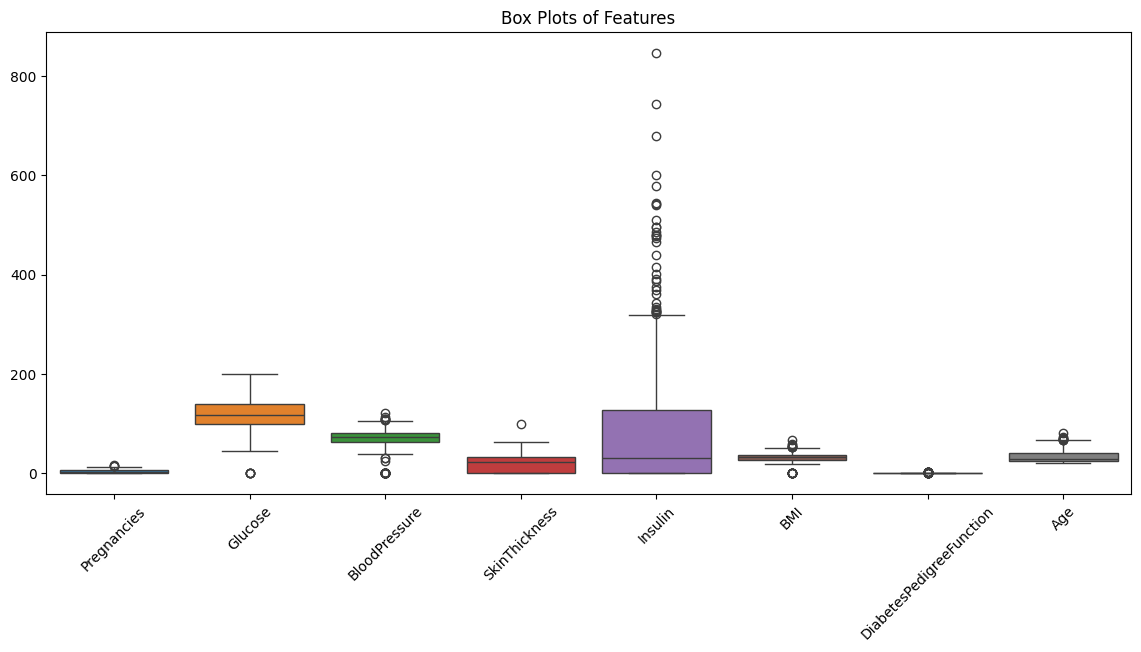

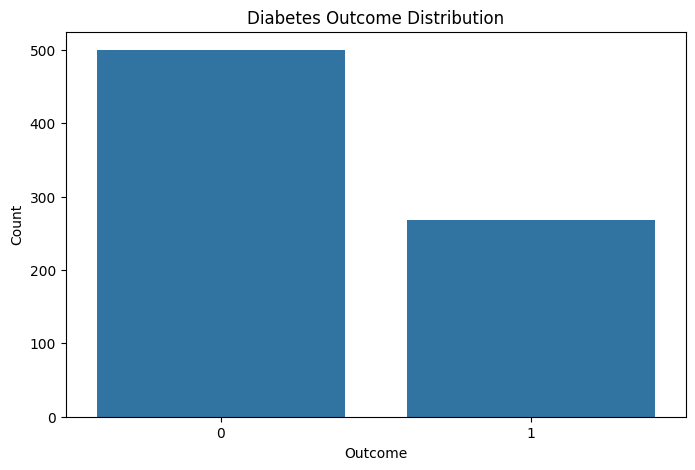

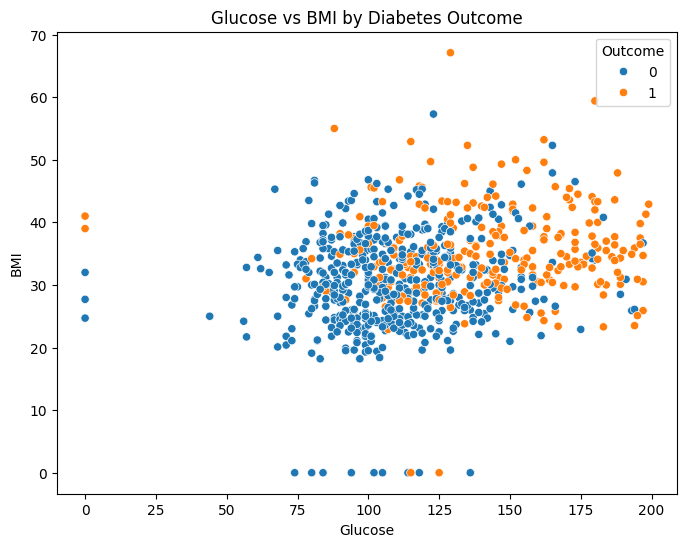

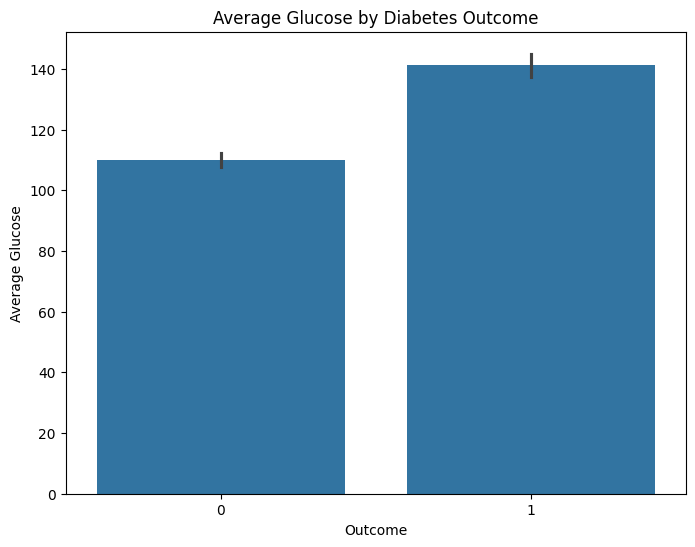

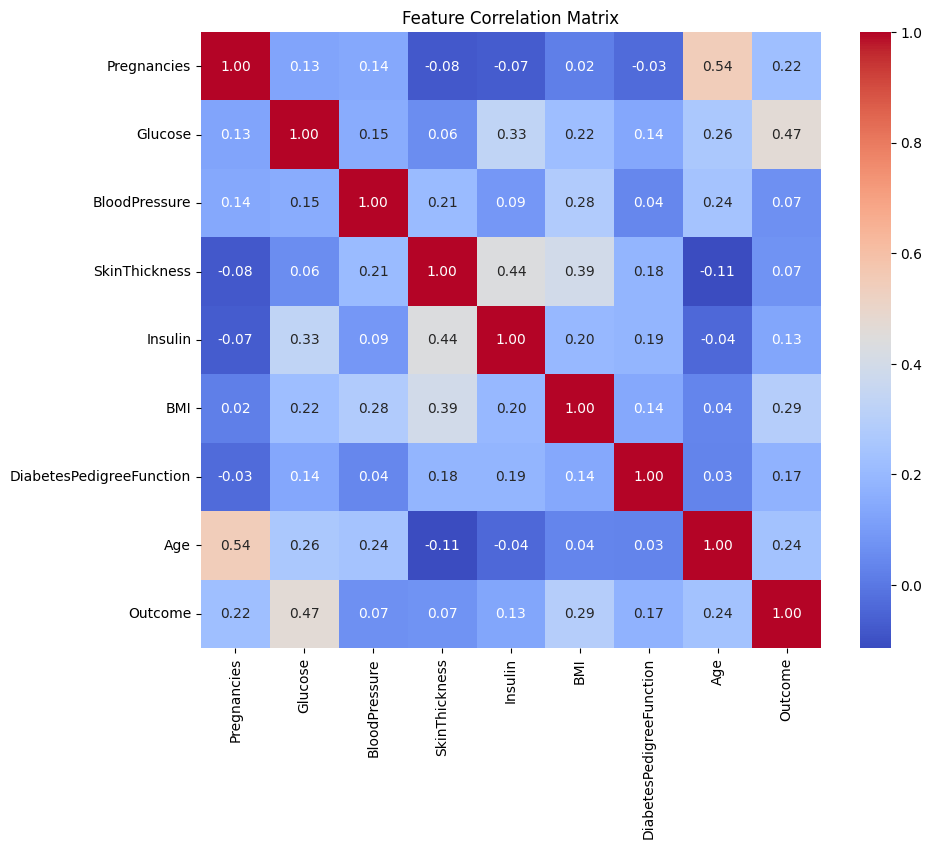

In [14]:

df.drop(columns=["Outcome"]).hist(figsize=(14, 10), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df.drop(columns=["Outcome"]))
plt.title("Box Plots of Features")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Outcome")
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Glucose", y="BMI", hue="Outcome")
plt.title("Glucose vs BMI by Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="Outcome", y="Glucose")
plt.title("Average Glucose by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Average Glucose")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

**Data Preprocessing**

In [15]:

X = df.drop(columns=["Outcome"]).copy()
y = df["Outcome"].copy()

zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

X[zero_as_missing] = X[zero_as_missing].replace(0, np.nan)

imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Missing Values After Imputation:")
print(X.isnull().sum())

print("\nCategorical Columns:")
print(X.select_dtypes(exclude=np.number).columns.tolist())

print("\nAll Features Are Numerical:")
print(X.dtypes)

Missing Values After Imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Categorical Columns:
[]

All Features Are Numerical:
Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
dtype: object


**Train-Test Split**

In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])
print("Training Features:", X_train.shape[1])

Training Samples: 614
Testing Samples: 154
Training Features: 8


**LightGBM Model**

In [17]:

lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, lgbm_pred))
print("LightGBM Precision:", precision_score(y_test, lgbm_pred, zero_division=0))
print("LightGBM Recall:", recall_score(y_test, lgbm_pred, zero_division=0))
print("LightGBM F1-Score:", f1_score(y_test, lgbm_pred, zero_division=0))

print("\nLightGBM Classification Report:")
print(classification_report(y_test, lgbm_pred, zero_division=0))

LightGBM Accuracy: 0.7662337662337663
LightGBM Precision: 0.68
LightGBM Recall: 0.6296296296296297
LightGBM F1-Score: 0.6538461538461539

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       100
           1       0.68      0.63      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



**XGBoost Model**

In [18]:

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGBoost Precision:", precision_score(y_test, xgb_pred, zero_division=0))
print("XGBoost Recall:", recall_score(y_test, xgb_pred, zero_division=0))
print("XGBoost F1-Score:", f1_score(y_test, xgb_pred, zero_division=0))

print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_pred, zero_division=0))

XGBoost Accuracy: 0.7402597402597403
XGBoost Precision: 0.6521739130434783
XGBoost Recall: 0.5555555555555556
XGBoost F1-Score: 0.6

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



**Cross Validation**

In [19]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgbm_cv = GridSearchCV(
    LGBMClassifier(random_state=42, verbosity=-1),
    {
        "n_estimators": [100, 200],
        "learning_rate": [0.03, 0.05],
        "num_leaves": [15, 31],
        "max_depth": [-1, 5]
    },
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

xgb_cv = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    {
        "n_estimators": [100, 200],
        "learning_rate": [0.03, 0.05],
        "max_depth": [3, 5],
        "subsample": [0.8, 1.0]
    },
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

lgbm_cv.fit(X_train, y_train)
xgb_cv.fit(X_train, y_train)

print("Best LightGBM Parameters:")
print(lgbm_cv.best_params_)
print("\nBest LightGBM CV F1-Score:", lgbm_cv.best_score_)

print("\nBest XGBoost Parameters:")
print(xgb_cv.best_params_)
print("\nBest XGBoost CV F1-Score:", xgb_cv.best_score_)

Best LightGBM Parameters:
{'learning_rate': 0.03, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31}

Best LightGBM CV F1-Score: 0.6384621886942561

Best XGBoost Parameters:
{'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}

Best XGBoost CV F1-Score: 0.6440173160173159


**Tuned Model Evaluation**

In [20]:

best_lgbm = lgbm_cv.best_estimator_
best_xgb = xgb_cv.best_estimator_

best_lgbm_pred = best_lgbm.predict(X_test)
best_xgb_pred = best_xgb.predict(X_test)

results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, best_lgbm_pred),
        accuracy_score(y_test, best_xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, best_lgbm_pred, zero_division=0),
        precision_score(y_test, best_xgb_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, best_lgbm_pred, zero_division=0),
        recall_score(y_test, best_xgb_pred, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, best_lgbm_pred, zero_division=0),
        f1_score(y_test, best_xgb_pred, zero_division=0)
    ]
})

print(results)

      Model  Accuracy  Precision    Recall  F1-Score
0  LightGBM  0.746753   0.641509  0.629630  0.635514
1   XGBoost  0.740260   0.652174  0.555556  0.600000


**Model Comparison Visualization**

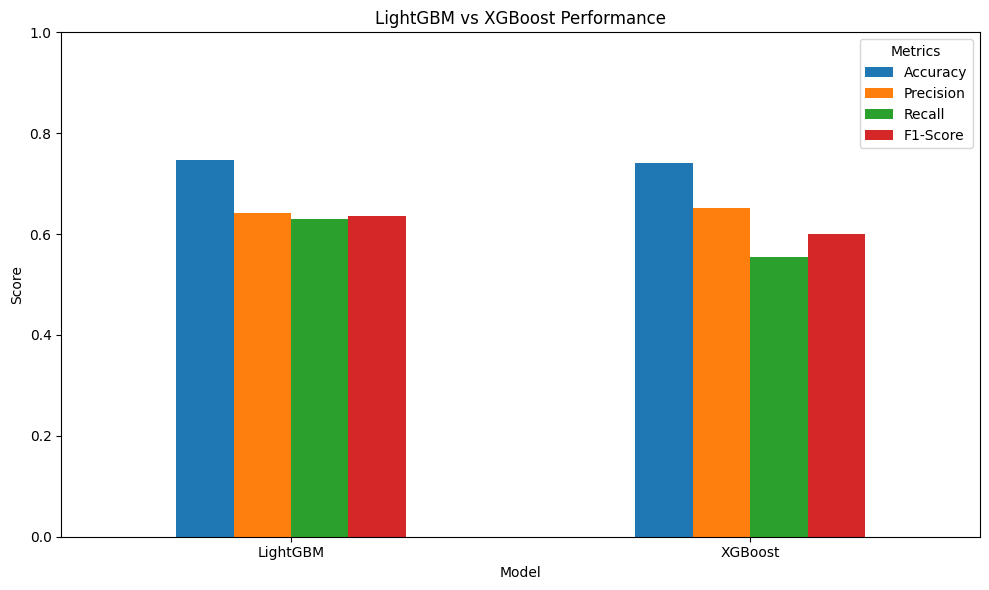

Performance Comparison:
          Accuracy  Precision    Recall  F1-Score
Model                                            
LightGBM  0.746753   0.641509  0.629630  0.635514
XGBoost   0.740260   0.652174  0.555556  0.600000


In [21]:

comparison = results.set_index("Model")

comparison.plot(kind="bar", figsize=(10, 6))
plt.title("LightGBM vs XGBoost Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

print("Performance Comparison:")
print(comparison)

**Feature Importance**

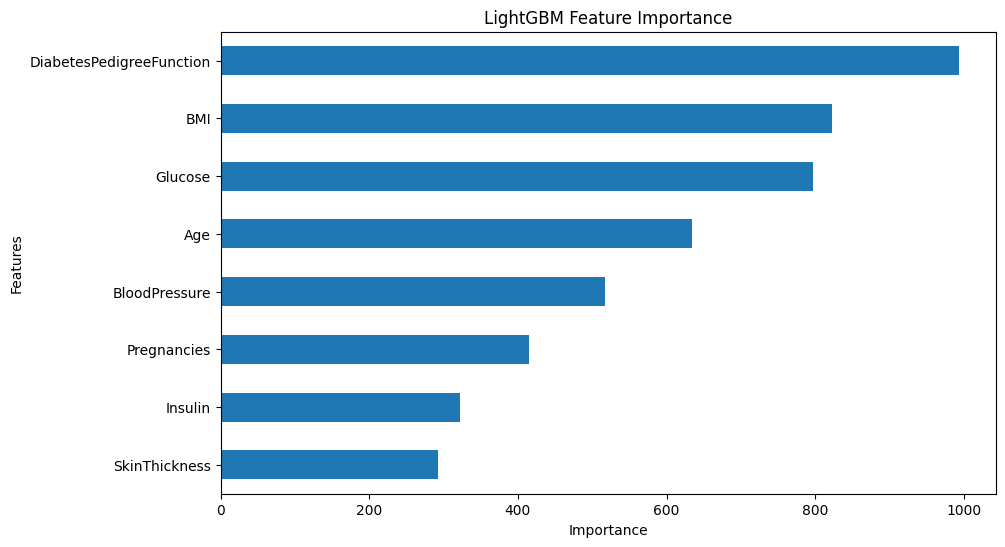

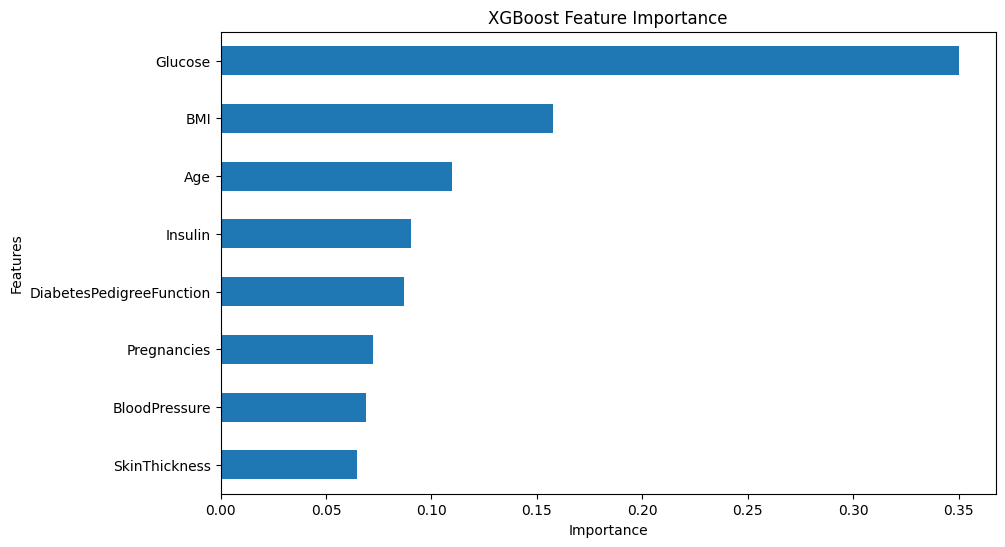

LightGBM Feature Importance:
DiabetesPedigreeFunction    993
BMI                         822
Glucose                     797
Age                         634
BloodPressure               517
Pregnancies                 415
Insulin                     322
SkinThickness               293
dtype: int32

XGBoost Feature Importance:
Glucose                     0.350037
BMI                         0.157509
Age                         0.109713
Insulin                     0.090366
DiabetesPedigreeFunction    0.086852
Pregnancies                 0.072095
BloodPressure               0.068826
SkinThickness               0.064603
dtype: float32


In [22]:

lgbm_importance = pd.Series(
    best_lgbm.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
lgbm_importance.sort_values().plot(kind="barh")
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

plt.figure(figsize=(10, 6))
xgb_importance.sort_values().plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

print("LightGBM Feature Importance:")
print(lgbm_importance)

print("\nXGBoost Feature Importance:")
print(xgb_importance)

##**Comparative Analysis**
LightGBM and XGBoost are both gradient boosting algorithms that build models sequentially to improve predictions.

**LightGBM strengths:** It is designed for fast and efficient training and can handle large datasets effectively. It uses a leaf-wise tree growth strategy.

**LightGBM weaknesses:** Its aggressive tree growth can sometimes lead to overfitting if the hyperparameters are not properly controlled.

**XGBoost strengths:** It provides strong predictive performance, regularization, and effective control over model complexity.

**XGBoost weaknesses:** It can require more computational resources and careful hyperparameter tuning.

The model with the better test-set performance should be selected based on the appropriate evaluation metrics, particularly F1-score, precision, and recall, rather than accuracy alone.

##**Practical Implications**
* The models can be used to predict whether a patient is likely to have diabetes based on the available health-related features. The comparison of LightGBM and XGBoost helps identify which model provides better predictive performance for this dataset.

* The final model should be selected based on the evaluation results and validated carefully before being considered for real-world medical decision-making.

* This completes the assignment requirements for EDA, preprocessing, LightGBM, XGBoost, cross-validation, hyperparameter tuning, comparative analysis, visualization, and practical implications.